<div class='alert alert-block alert-info"'>
<h1> Application to plant senescence genetic marker
identification :</h1>

<h4> Estimation and variable selection in an Mixed-effect models </h4>

In [1]:
import sdg4varselect.plot as sdgplt
import jax.numpy as jnp
import jax.random as jrd

### Joint Model Specification

$$ \left\{\begin{array}{rll}
            h(t|U_i) 
            &=h_{0}(t) \exp(\beta^T U_i + \alpha m(t,\varphi_i))
            \\ Y_{i,j} &= m(t_j; \varphi_i) + \varepsilon_{i,j}
            \\ \varphi_i \sim \mathcal N(\mu, \Gamma)   
            & ; ~\varepsilon_{i,j} \sim \mathcal N(0,\sigma^2).             
        \end{array}\right. ~ \forall i \in\{1,...,N\}, j\in\{1,...,J\}$$

where : $h_{0}(t)= b a^{-b} t^{b-1}$ with $a=80$ and $b=35$

#### NLMEM Specification

First, let's define the model with the abstract object AbstractMixedEffectsModel. We want to define the following logisitc models :

$$ \left\{\begin{array}{rll}
            Y_{i,j} &= m(t_{i,j}; \varphi_i) + \varepsilon_{i,j}
            \\ \varphi_i \sim \mathcal N(\mu, \Gamma)   
            & ; ~\varepsilon_{i,j} \sim \mathcal N(0,\sigma^2).             
        \end{array}\right. ~ \forall i \in\{1,...,N\}, j\in\{1,...,J\}$$

where : $m(t_{i,j}; \varphi) = \frac{\varphi_{1,i}}{1+\exp\left(\frac{\varphi_{2,i}-t_{i,j}}{\tau} \right)}$ 

In [2]:
import functools

from jax import jit
import jax.numpy as jnp
import jax.random as jrd

import parametrization_cookbook.jax as pc


from sdg4varselect.models import (
    AbstractMixedEffectsModel,
    AbstractHDModel,
    cov_simulation,
)


class LogisticMixedEffectsModel(AbstractMixedEffectsModel, AbstractHDModel):
    """define a logistic mixed effects model"""

    def __init__(self, N=1, J=1, P=1, **kwargs):
        AbstractMixedEffectsModel.__init__(
            self,
            N=N,
            J=J,
            me_name=["phi1", "phi2"],
            **kwargs,
        )
        AbstractHDModel.__init__(self, P=P)

        self.init()

    @property
    def name(self):
        """return a str called name, based on the parameter of the model"""
        return f"LogisticMEM_N{self.N}_J{self.J}_P{self.P}"

    def init(self):
        """here you define the parametrization of the model
        and don't forget to call the mother init function at the end"""
        self._parametrization = pc.NamedTuple(
            mean_latent=pc.NamedTuple(
                mu1=pc.RealPositive(scale=100),
                mu2=pc.RealPositive(scale=2000),
            ),
            tau=pc.RealPositive(scale=100),
            cov_latent=pc.MatrixDiagPosDef(dim=2, scale=(2000, 2000)),
            # cov_latent=pc.MatrixSymPosDef(dim=2, scale=(2000, 2000)),
            var_residual=pc.RealPositive(scale=100),
            beta=pc.Real(scale=10, shape=(self.P,)),
        )
        AbstractHDModel.init_dim(self)

    # ============================================================== #
    @functools.partial(jit, static_argnums=0)
    def mixed_effect_function(
        self,
        params,
        times: jnp.ndarray,  # shape = (J,) [None, :]
        phi1: jnp.ndarray,  # shape = (N,) [:,None]
        phi2: jnp.ndarray,  # shape = (N,) [:,None]
        cov: jnp.ndarray,  # shape = (N,p)
        **kwargs,
    ) -> jnp.ndarray:  # shape = (N,J)
        """logistic_curve
        phi1 = supremum
        phi2 = midpoint
        tau = growth rate
        """
        ksi = cov @ params.beta + phi2

        out = phi1[:, None] / (1 + jnp.exp(-(times - ksi[:, None]) / params.tau))
        assert out.shape == times.shape
        return out

    # ============================================================== #

    def sample(
        self,
        params_star,
        prngkey,
        **kwargs,
    ):
        """Sample one data set for the model"""

        (
            prngkey_mem,
            prngkey_cov,
        ) = jrd.split(prngkey, num=3)

        # === nlmem_simulation() === #
        def interval(a, b, n_pts):
            return a + jnp.arange(0, n_pts) * (b - a) / n_pts

        interval_percentage = [(0, 0.3), (0.35, 0.5), (0.6, 1.0)]
        A, B = 150, 3000
        BsubA = B - A
        time = jnp.array([])
        for a, b in interval_percentage:
            time = jnp.concatenate(
                [
                    time,
                    interval(
                        A + a * BsubA, A + b * BsubA, self.J // len(interval_percentage)
                    ),
                ]
            )

        time = jnp.repeat(time[None, :], self.N, axis=0)
        cov = cov_simulation(prngkey_cov, cov_min=-1, cov_max=1, shape=(self.N, self.P))

        obs, sim = AbstractMixedEffectsModel.sample(
            self, params_star, prngkey_mem, mem_obs_time=time, cov=cov
        )

        return {"mem_obs_time": time, "cov": cov} | obs, sim

In [3]:
import pandas as pd
from sdg4varselect.outputs import TestResults

seed_name = "S(1, 100)"
m = LogisticMixedEffectsModel
config = [
    # {"N": 200, "J": 15, "P": 5}, f"S0"
    {"N": 100, "J": 15, "P": 500},
    # {"N": 200, "J": 15, "P": 500},
    {"N": 100, "J": 15, "P": 1000},
]
results = TestResults(
    [TestResults.load(m(**c), "files", filename_add_on=seed_name) for c in config],
    config,
)
nrun_to_keep = min([len(t) for t in results])
results = TestResults(
    [t.reduce_number_run(nrun_to_keep) for t in results], results.config
)

print(f"chrono = {[str(t.chrono) for t in results]}")
print([len(t) for t in results])


pd.DataFrame(
    [
        [str(t.chrono / t.total_number_res) for t in results],
        [str(t.chrono / len(t[0])) for t in results],
    ],
    index=[
        "by fit",
        f"by estimation ( {results[0].total_number_res/len(results[0])} fits)",
    ],
    columns=[f'N = {c["N"]}, P = {c["P"]}' for c in results.config],
).T

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


files/LogisticMEM_N100_J15_P500_S(1, 100) LOADED !
files/LogisticMEM_N100_J15_P1000_S(1, 100) LOADED !
chrono = ['57 days, 3:05:48.281478', '21 days, 18:25:05.932938']
[100, 100]


,by fit,by estimation ( 20.0 fits)
"N = 100, P = 500",0:41:07.974141,"5 days, 17:06:34.828148"
"N = 100, P = 1000",0:15:40.352966,"2 days, 4:14:30.593294"


In [4]:
myModel = m(200, 15, P=max([c["P"] for c in results.config]))

p_star = myModel.new_params(
    mean_latent={"mu1": 100, "mu2": 1200},
    cov_latent=jnp.diag(jnp.array([40, 200])),
    tau=150,
    var_residual=30,
    beta=jnp.concatenate([jnp.array([80, 30, 20]), jnp.zeros(shape=(myModel.P - 3,))]),
)

Vérification de la réparition des estimations par rapport à la vraissemblance

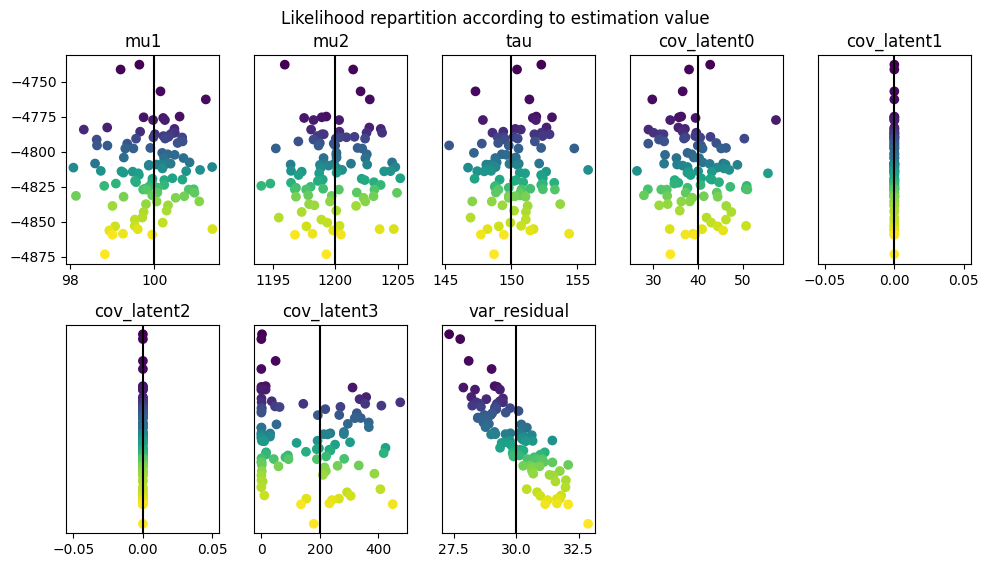

In [5]:
fig = sdgplt.figure(height=8, width=10)
results[-1].sort()

_ = sdgplt.scatter_estimation(
    results[-1].last_theta[:, 1, : myModel.DIM_LD].T,
    results[-1].likelihood[:, 1],
    vline=myModel.hstack_params(p_star)[: myModel.DIM_LD],
    labels=myModel.params_names[: myModel.DIM_LD],
    nrows=3,
    ncols=5,
    fig=fig,
)

fig.tight_layout()

_ = fig.suptitle("Likelihood repartition according to estimation value", y=1.01)

Regularization path check

[0] 0
[1] 1
[2] 2
[3] 3
[4] 4
[5, 6, 7, 8, 9] 6


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


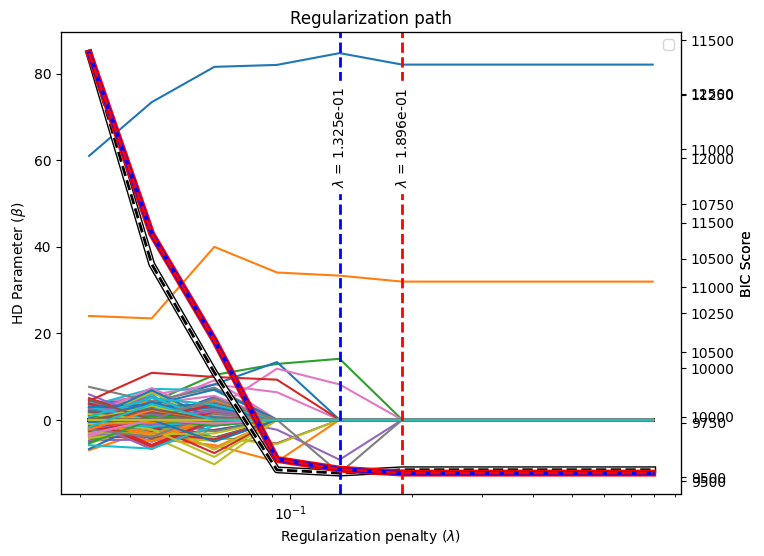

In [13]:
from sdg4varselect._regularization_function import eBIC

step = 1

reg_res = results[-1][0].standardize()  # .filter(P=300)[0]
fig = sdgplt.plot_reg_path(
    reg_res=reg_res, dim_ld=myModel.DIM_LD, fig=sdgplt.figure(6, 8)
)
ax = fig.axes[0]

x = jnp.array([r.last_theta[step, myModel.DIM_LD :] for r in reg_res])
t = jnp.array([xx[~jnp.isnan(xx)] for xx in x])

ebic = eBIC(
    t,
    jnp.array([r.likelihood[step] for r in reg_res]),
    myModel.N * (1 + myModel.J),
)

sdgplt._plot_bic(
    ax=ax,
    lbd_set=reg_res.lbd_set,
    bic=ebic,
    argmin_bic=jnp.argmin(ebic),
    colors=["r", "b", "r"],
    msg="eBIC",
)

ax.legend()

['$\\mu_1$' '$\\mu_2$' '$\\tau$' '$\\gamma^2_1$' '$\\gamma^2_2$'
 '$\\sigma^2$' '$\\beta$' '$\\beta_1$' '$\\beta_2$']


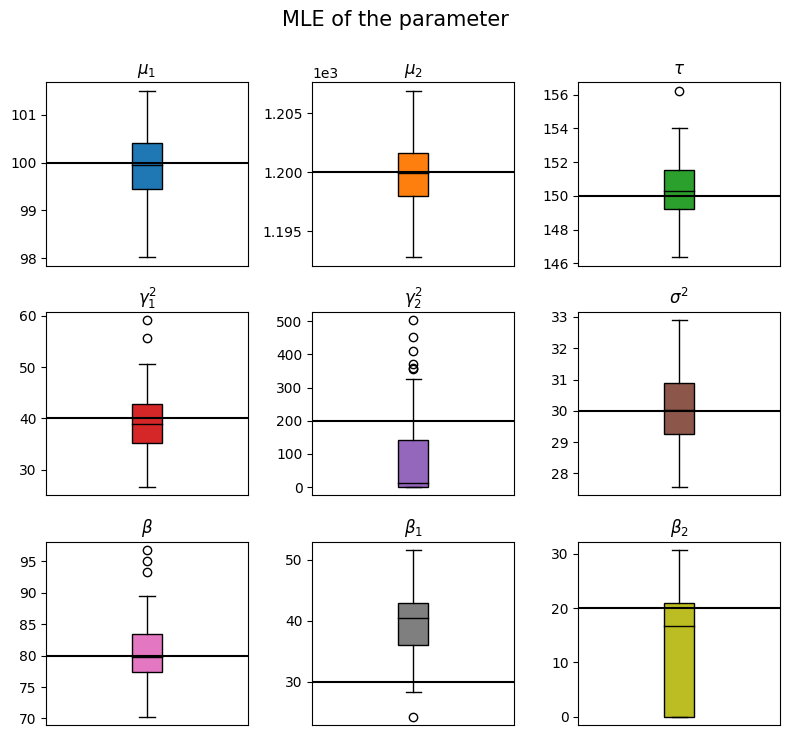

In [14]:
import numpy as np

params_names = np.array(
    [
        "$\\mu_1$",
        "$\\mu_2$",
        "$\\tau$",
        "$\\gamma^2_1$",
        "$\\gamma^2_{12}$",
        "$\\gamma^2_{21}$",
        "$\\gamma^2_2$",
        "$\\sigma^2$",
        "$\\beta$",
    ]
    + [f"$\\beta_{i+1}$" for i in range(myModel.P)]
)

r = results[0]  # .filter(P=500, N=200)
# scenarios_labels = [
#     f"{n}\n{p}"
#     for n, p in zip(
#         r.get_scenarios_labels("N"), r.get_scenarios_labels("P")
#     )
# ]
id = np.array([1, 2, 3, 4, 7, 8, 9, 10, 11]) - 1

print(params_names[id])
x = r.last_theta[:, 1, id]
fig = sdgplt.boxplot_estimation(
    x=x.T,
    hline=myModel.hstack_params(p_star)[id],
    # xlabels=scenarios_labels,
    title=params_names[id],
    nrows=3,
    ncols=3,
    fig=sdgplt.figure(height=7, width=8),
)

for ax in fig.axes:
    ax.tick_params(axis="x", labelrotation=45)
fig.tight_layout()
_ = fig.suptitle("MLE of the parameter", fontsize=15, y=1.05)

(2, 100, 1000)


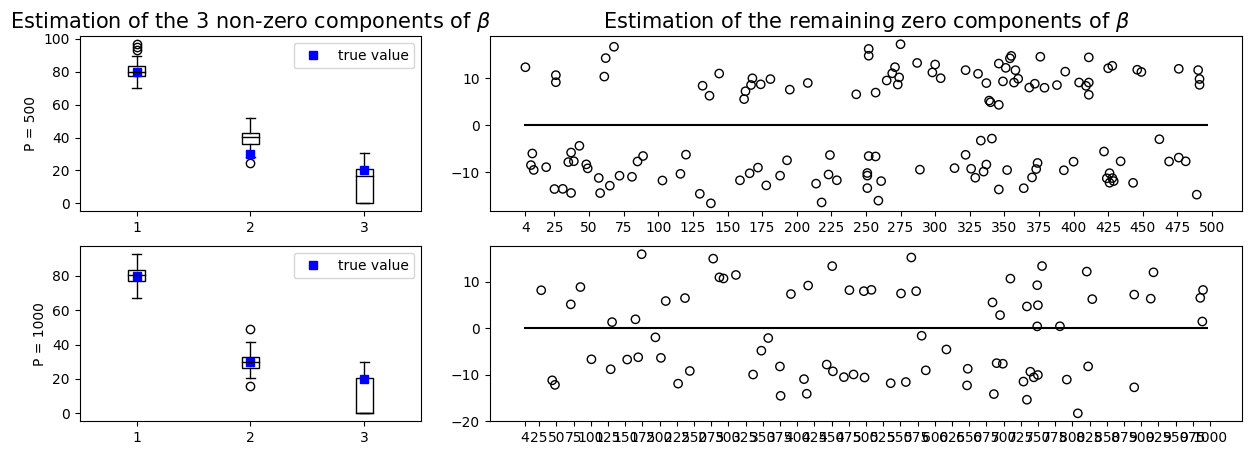

In [15]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# res = results.filter(N=200, P=500, keep_type=True)
res = results  # .filter(N=100, keep_type=True).sort("P")

params_star_HD = p_star.beta
import numpy as np

n_method = -1
non_zero = 3

theta = np.array(res.last_theta)[:, :, n_method, myModel.DIM_LD :]

print(theta.shape)

G = GridSpec(len(res), 3)
fig = sdgplt.figure()

scenarios_labels = [
    f"{n}\n{p}"
    for n, p in zip(res.get_scenarios_labels("N"), res.get_scenarios_labels("P"))
]
scenarios_labels = res.get_scenarios_labels("P")

P_max = theta.shape[-1]
xticks = jnp.arange(0, P_max) + 1
for i in range(len(res)):
    ax = plt.subplot(G[i, 0])

    sdgplt.myBoxplot(
        ax=ax, x=theta[i][:, :non_zero].T, xlabels=[f"{k+1}" for k in range(non_zero)]
    )
    ax.plot(xticks[:non_zero] - 1, params_star_HD[:non_zero], "bs", label="true value")

    ax.legend()
    ax.set_ylabel(scenarios_labels[i])
    # == == == == #
    ax = plt.subplot(G[i, 1:])  # , sharey=ax)
    tt = theta[i][:, non_zero:].T
    theta_nonan = tt[jnp.array([~jnp.isnan(xx).any() for xx in tt]), :]

    # sdgplt.myBoxplot(ax = ax, x = theta_nonan)
    points = sum(
        [
            [(i + non_zero, xx) for xx in theta_nonan[i] if xx != 0]
            for i in range(theta_nonan.shape[0])
            if jnp.abs(theta_nonan[i]).sum() != 0
        ],
        [],
    )

    ax.scatter(
        [p[0] for p in points],
        [p[1] for p in points],
        facecolors="none",
        edgecolors="k",
    )
    ax.hlines(0, xmin=non_zero, xmax=theta_nonan.shape[0], colors="k")

    xticks_nonzero = [non_zero + 1] + [
        (x + 1) * 25 for x in range((theta_nonan.shape[0] + non_zero) // 25)
    ]

    ax.set_xticks(xticks_nonzero, [str(x) for x in xticks_nonzero])

ax = plt.subplot(G[0, 0])
ax.set_title(
    f"Estimation of the {non_zero} non-zero components of $\\beta$", fontsize=15
)
ax = plt.subplot(G[0, 1:])  # , sharey=ax)
ax.set_title(f"Estimation of the remaining zero components of $\\beta$", fontsize=15)


fig.set_figheight(8)
fig.set_figheight(5)
fig.set_figwidth(15)

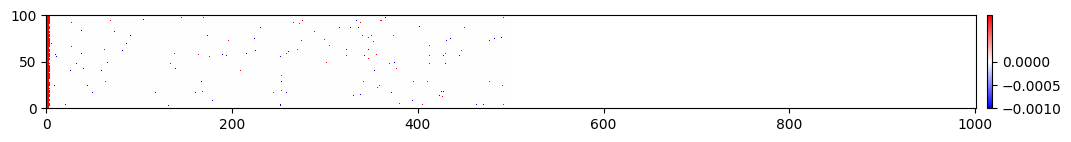

In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np

theta = jnp.array(
    [jnp.array([(res[-1][7:]) for res in test]) for test in results.last_theta]
)[0]

params_star_HD = p_star[9 : 9 + theta.shape[1]] != 0
correct_model = jnp.array([params_star_HD == t for t in theta]).mean(axis=1)

correct_model_sum = (
    jnp.array(
        [
            jnp.array(correct_model == 1).sum(),
            jnp.logical_and(0.9 <= correct_model, correct_model < 1).sum(),
            jnp.array(correct_model < 0.9).sum(),
        ]
    )
    / correct_model.shape[0]
)


fig = sdgplt.figure()
ax = fig.add_subplot(1, 1, 1)


def meshgrid(ax, dt):
    x_abs = 0.5 + np.arange(dt.shape[1])
    y_ord = 0.5 + np.arange(dt.shape[0])
    x, y = np.meshgrid(x_abs, y_ord)

    vmin = dt.min() if dt.min() < 0 else -0.001
    vmax = dt.max() if dt.max() > 0 else 0.0001

    colormesh = ax.pcolormesh(
        x,
        y,
        dt,
        cmap=plt.colormaps["bwr"],
        norm=colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax),
    )

    ax.set_aspect("equal")

    # cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
    cb = fig.colorbar(colormesh, ax=ax)  # , location="right")

    return ax, cb


ax, cb = meshgrid(ax, theta[np.argsort(correct_model), :])
cb_pos = cb.ax.get_position()
ax_pos = ax.get_position()
cb.ax.set_position([ax_pos.xmax * 1.01, ax_pos.ymin, ax_pos.width, ax_pos.height])

## RMSE estimation P = 500

In [10]:
import numpy as np


def table_rmse_article(results):
    # last_theta_estim =
    params_names = np.array(
        [
            "$\\mu$",
            "$\\psi_1$",
            "$\\psi_2$",
            "$\\gamma^2_1$",
            "$\\sigma^2$",
            "$\\beta$",
        ]
        + [f"$\\beta_{i+1}$" for i in range(myModel.P)]
    )

    df = []
    for i in range(len(results)):
        pd_df = sdgplt.get_dataframe_results(
            results[i].last_theta[
                :, -1, : myModel.DIM_LD + 3
            ],  # last_theta_estim[:, : myModel.DIM_LD],
            myModel.hstack_params(p_star)[: myModel.DIM_LD + 3],
            params_names[: myModel.DIM_LD + 3],
        )

        pd_df = pd_df.drop("real value", axis=1)
        # pd_df = pd_df.drop("RRMSE", axis=1)
        # pd_df= pd_df.drop("RMSE", axis = 1)
        pd_df = pd_df.drop("mean", axis=1)
        pd_df = pd_df.drop("variance", axis=1)

        df.append(pd_df)

    col = pd.MultiIndex.from_arrays(
        [
            np.repeat([f'{c["N"]}' for c in results.config], len(pd_df.index)),
            np.tile(pd_df.index, len(results)),
        ]
    )
    col = sum([[l, l] for l in results.get_scenarios_labels("P")], [])

    pd_df = pd.concat(df, axis=1)
    print(pd_df.index)

    pd_df = pd.DataFrame(
        pd_df.to_numpy(),
        columns=pd.MultiIndex.from_arrays(
            [
                np.repeat([f" N = {results.config[0]['N']}"], len(pd_df.columns)),
                col,  # pd_df.columns,
            ]
        ),
        index=pd_df.index,
    )

    print(pd_df.to_latex(float_format="{:.3f}".format))

    return pd_df.style.format("{:.2f}".format)


table_rmse_article(results.filter(N=200, keep_type=True).sort("N"))

IndexError: list index out of range

### Variable selection numerical proof

In [ ]:
def get_support_star(x, x_star):
    xx_star = jnp.tile(p_star.beta, reps=x.shape[:-1] + (1,))
    return jnp.where(jnp.isnan(x), jnp.nan, xx_star != 0)


support_star = get_support_star(
    results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta
)
print(support_star.shape)


def get_support(x, x_star):
    if len(x.shape) > 1:
        return jnp.array([get_support(xx, x_star) for xx in x])

    return jnp.where(jnp.isnan(x), jnp.nan, x != 0)


multi_support = get_support(results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta)
print(multi_support.shape)

(3, 100, 1000)
(3, 100, 1000)


[[ 3.  3.  3.  3.  7.  3.  2.  4.  6.  6.  5.  3.  3.  3.  3.  3.  6.  3.
   3.  2.  3.  3. 10.  3.  4.  2.  3.  3.  3.  3.  3.  6.  4.  3.  2.  3.
   6.  3.  2.  5.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  2.  3.  3.
   5.  7.  4.  3.  3.  3.  3.  5.  3.  4.  2.  3.  3.  3.  3.  5.  3.  3.
   3.  2.  3.  3.  3.  3.  3.  3.  5.  3.  3.  6.  3.  3.  3.  3.  3.  3.
   3.  6.  3.  3.  4.  3.  3.  4.  6.  3.]
 [ 3.  4.  3.  5.  3.  3.  4.  3.  3.  3.  3.  3. 12.  3.  3.  3.  3.  3.
   3.  3.  2.  3.  3.  6.  2.  3.  3.  4.  3.  3.  3.  3.  3.  3.  3.  3.
   3.  2.  2.  3.  3.  3.  3.  2.  3.  3.  3.  5.  3.  3.  3.  5.  2.  4.
  10.  3.  2.  3.  3.  3.  3.  4.  3.  3.  3.  3.  2.  4.  3. 10.  3.  3.
   2.  3.  3.  3.  3.  3.  8.  3.  3.  8.  3.  3.  4.  3.  3.  3.  3.  3.
   2.  2.  3.  2.  3.  3.  2.  3.  3.  2.]]


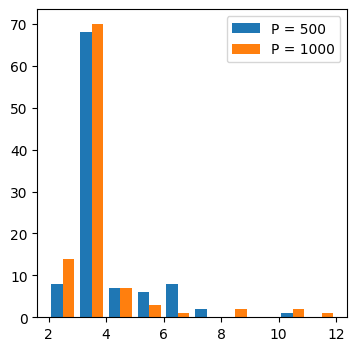

In [ ]:
def hist(results):
    support_star = get_support_star(
        results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta
    )

    multi_support = get_support(
        results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta
    )
    ax = sdgplt.get_ax(4, 4)
    print(jnp.nansum(multi_support, axis=-1))
    h = ax.hist(
        jnp.nansum(multi_support, axis=-1), label=results.get_scenarios_labels("P")
    )
    ax.legend()


hist(results.filter(N=200).sort("P"))

In [ ]:
def table_accuracy_article(results):

    support_star = get_support_star(
        results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta
    )

    multi_support = get_support(
        results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta
    )

    ds = jnp.abs(multi_support - support_star)
    # TP/total P
    TP = jnp.nansum(ds[:, :, :3], axis=-1)
    sensitivity = 1 - jnp.nanmean(ds[:, :, :3], axis=-1)
    # TN / total N
    TN = jnp.nansum(ds[:, :, 3:], axis=-1)
    specificity = 1 - jnp.nanmean(ds[:, :, 3:], axis=-1)
    # (TP+TN)/dim
    accuracy = 1 - jnp.nansum(ds, axis=-1)
    accuracy = 1 - jnp.nanmean(ds, axis=-1)

    dx = jnp.abs(results.last_theta[:, :, -1, myModel.DIM_LD :] - p_star.beta)
    L1 = jnp.nansum(dx, axis=-1)
    L2 = jnp.sqrt(jnp.nansum(dx**2, axis=-1))

    x = jnp.array([sensitivity, specificity, accuracy, L1, L2])
    y = [x.mean(axis=-1), jnp.sqrt(x.var(axis=-1))]
    df = jnp.column_stack(
        [jnp.column_stack([y[0][i], y[1][i]]) for i in range(x.shape[0])]
    )
    df = jnp.concatenate([jnp.stack([y[0].T[i], y[1].T[i]]) for i in range(x.shape[1])])

    col = [
        "sensitivity",
        "specificity",
        "accuracy",
        "L1",
        "L2",
    ]
    # col = pd.MultiIndex.from_arrays(
    #     [ sum([[i]*2 for i in range(5)],[]),
    #         ["mean", "var"] * 5,
    #     ]
    # )

    pd_df = pd.DataFrame(
        df,
        columns=col,
        index=sum([[f'N = {c["N"]}, P = {c["P"]}', ""] for c in results.config], []),
    )

    print(pd_df.to_latex(float_format="{:.3f}".format))

    # .style.format(["{:.3%}".format, "{:.1}".format]*5)
    # {
    #     "sensitivity": "{:.3%}".format,
    #     "specificity": "{:.3%}".format,
    #     "accuracy": "{:.3%}".format,
    #     "L1": "{:.1f}".format,
    #     "L2": "{:.1f}".format,
    # }
    return pd_df.style.format("{:.2}".format)


table_accuracy_article(results.sort("P"))
# table_accuracy_article(results.filter(P=500).sort("N"))

\begin{tabular}{lrrrrr}
\toprule
 & sensitivity & specificity & accuracy & L1 & L2 \\
\midrule
N = 100, P = 500 & 0.863 & 0.997 & 0.997 & 29.359 & 17.031 \\
 & 0.164 & 0.004 & 0.004 & 17.497 & 7.072 \\
N = 200, P = 500 & 0.973 & 0.999 & 0.999 & 13.469 & 8.102 \\
 & 0.090 & 0.002 & 0.002 & 10.670 & 5.646 \\
N = 200, P = 1000 & 0.953 & 1.000 & 0.999 & 13.667 & 8.723 \\
 & 0.116 & 0.002 & 0.002 & 12.496 & 6.351 \\
\bottomrule
\end{tabular}



,sensitivity,specificity,accuracy,L1,L2
"N = 100, P = 500",0.86,1.0,1.0,2.9e+01,1.7e+01
,0.16,0.0039,0.0035,1.7e+01,7.1
"N = 200, P = 500",0.97,1.0,1.0,1.3e+01,8.1
,0.09,0.0025,0.0024,1.1e+01,5.6
"N = 200, P = 1000",0.95,1.0,1.0,1.4e+01,8.7
,0.12,0.0015,0.0015,1.2e+01,6.4


In [ ]:

support_star = get_support_star(
    results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta
)

multi_support = get_support(results.last_theta[:, :, -1, myModel.DIM_LD :], p_star.beta)

all_component = jnp.nansum(jnp.abs(multi_support - support_star), axis=-1) == 0
first_component = (multi_support == support_star)[:, :, :3].mean(axis=-1) == 1
overselection = jnp.logical_and(first_component, jnp.logical_not(all_component))

score_support = jnp.array([all_component, overselection]).mean(axis=-1).T

pd.DataFrame(score_support, col = ["Exact", "Over"], index = )


SyntaxError: invalid syntax (4249805972.py, line 13)

[[0.22999999 0.35999998]
 [0.68       0.24      ]
 [0.7        0.16      ]]


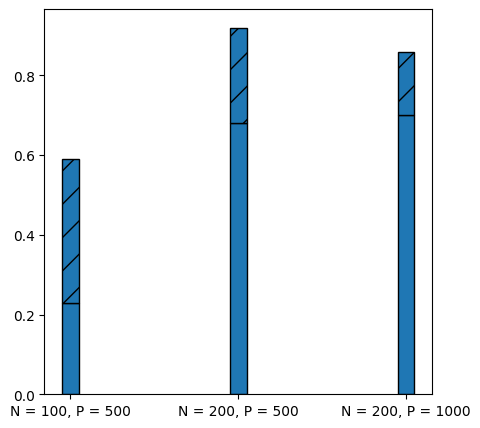

In [ ]:
all_component = jnp.nansum(jnp.abs(multi_support - support_star), axis=-1) == 0
first_component = (multi_support == support_star)[:, :, :3].mean(axis=-1) == 1
overselection = jnp.logical_and(first_component, jnp.logical_not(all_component))

score_support = jnp.array([all_component, overselection]).mean(axis=-1).T
print(score_support)

labels = ["Exact", "Over-selection"]
hatchs = ["", "/"]

scenarios_labels = sum([[f'N = {c["N"]}, P = {c["P"]}'] for c in results.config], [])

ax = sdgplt.get_ax(5, 5)
for i in range(score_support.shape[0]):
    for j in range(len(labels)):
        ax.bar(
            scenarios_labels[i],
            score_support[i, j],
            label=labels[j],
            bottom=score_support[i, :j].sum(axis=0),
            color=f"C{0}",
            edgecolor="black",
            width=0.1,
            hatch=hatchs[j],
        )